# Iris QML Classification (Standalone)

This notebook is dedicated to the Iris classification task only.
It compares Logistic Regression, RBF-SVM, and QSVC on PCA-2D features with runtime-safe plotting.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import ZZFeatureMap

try:
    from qiskit.circuit.library import zz_feature_map
except ImportError:
    zz_feature_map = None

from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

BASE_DIR = Path.cwd()
ASSETS_DIR = BASE_DIR / 'assets'
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 7

def build_zz_feature_map(feature_dimension: int, reps: int = 2, entanglement: str = 'linear'):
    if zz_feature_map is not None:
        return zz_feature_map(feature_dimension=feature_dimension, reps=reps, entanglement=entanglement)
    return ZZFeatureMap(feature_dimension=feature_dimension, reps=reps, entanglement=entanglement)

def estimate_kernel_evals(train_size: int, grid_resolution: int) -> int:
    grid_points = grid_resolution * grid_resolution
    return (train_size * train_size) + (grid_points * train_size)

def choose_quantum_grid(train_size: int, max_kernel_evals: int, floor: int = 12, cap: int = 80) -> int:
    for resolution in range(cap, floor - 1, -1):
        if estimate_kernel_evals(train_size, resolution) <= max_kernel_evals:
            return resolution
    return floor


In [2]:
iris = load_iris()
x_train, x_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=iris.target,
)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

scaler = StandardScaler()
x_train_pca = scaler.fit_transform(x_train_pca)
x_test_pca = scaler.transform(x_test_pca)

x_all_pca = np.vstack([x_train_pca, x_test_pca])
y_all = np.concatenate([y_train, y_test])

quantum_grid = choose_quantum_grid(train_size=len(x_train_pca), max_kernel_evals=120_000)
print(f'Chosen quantum grid: {quantum_grid} (estimated evals={estimate_kernel_evals(len(x_train_pca), quantum_grid)})')


Chosen quantum grid: 30 (estimated evals=113344)


In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Classical RBF-SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'Quantum SVC (ZZ-Map)': QSVC(
        quantum_kernel=FidelityQuantumKernel(
            feature_map=build_zz_feature_map(feature_dimension=2, reps=2, entanglement='linear')
        )
    ),
}

metrics = {}
for name, model in models.items():
    model.fit(x_train_pca, y_train)
    acc = accuracy_score(y_test, model.predict(x_test_pca))
    metrics[name] = {'test_accuracy': round(float(acc), 6)}
    print(f'{name} test accuracy: {acc:.4f}')


Logistic Regression test accuracy: 0.9737
Classical RBF-SVM test accuracy: 0.9737


Quantum SVC (ZZ-Map) test accuracy: 0.6316


Saved plot: C:\Users\devad\PycharmProjects\Quantum-AI-Research-Series\01-Classical-vs-Quantum-Visualization\assets\classical_vs_quantum_boundaries.png


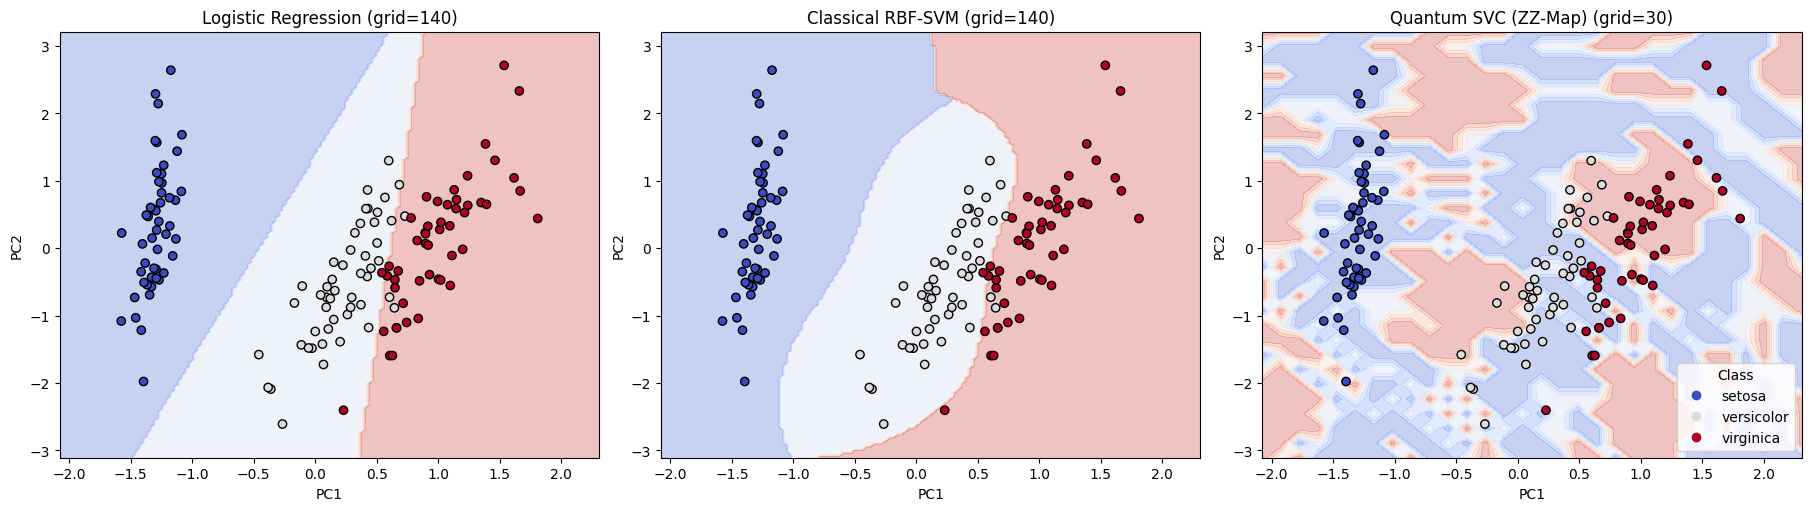

In [4]:
def plot_decision_surface(ax, model, x_plot, y_plot, title: str, resolution: int):
    x_min, x_max = x_plot[:, 0].min() - 0.5, x_plot[:, 0].max() + 0.5
    y_min, y_max = x_plot[:, 1].min() - 0.5, x_plot[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.30, cmap='coolwarm')
    scatter = ax.scatter(x_plot[:, 0], x_plot[:, 1], c=y_plot, cmap='coolwarm', edgecolor='black', s=36)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    return scatter

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (name, model) in zip(axes, models.items()):
    resolution = quantum_grid if isinstance(model, QSVC) else 140
    scatter = plot_decision_surface(ax, model, x_all_pca, y_all, f'{name} (grid={resolution})', resolution)

handles, _ = scatter.legend_elements()
axes[-1].legend(handles, iris.target_names, title='Class', loc='best')

plot_path = ASSETS_DIR / 'classical_vs_quantum_boundaries.png'
fig.savefig(plot_path, dpi=220, bbox_inches='tight')
print(f'Saved plot: {plot_path}')
plt.show()


In [5]:
report = {
    'random_state': RANDOM_STATE,
    'train_size': len(x_train_pca),
    'test_size': len(x_test_pca),
    'pca_explained_variance_ratio': [float(v) for v in pca.explained_variance_ratio_],
    'grid_resolution': {'classical': 140, 'quantum': quantum_grid},
    'quantum_kernel_eval_estimate': estimate_kernel_evals(len(x_train_pca), quantum_grid),
    'quantum_max_kernel_evals_budget': 120000,
    'metrics': metrics,
    'plot_path': str(plot_path),
}

report_path = ASSETS_DIR / 'qml_iris_report.json'
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')
print(f'Saved report: {report_path}')


Saved report: C:\Users\devad\PycharmProjects\Quantum-AI-Research-Series\01-Classical-vs-Quantum-Visualization\assets\qml_iris_report.json


## Interpretation

- Classical models remain stronger on Iris in this setup.
- QSVC runs here as a controlled kernel-mapping demonstration, not a quantum advantage claim.
- The runtime-safe quantum grid avoids runaway fidelity kernel workloads during boundary plotting.
